In [3]:
import pandas as pd
import numpy as np
import difflib
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Load and Smart-Clean Data
df = pd.read_csv('ex.csv',encoding = "latin")
df.fillna('', inplace=True)

# Fix Rating column errors (e.g., '10-Oct')
def fix_rating(x):
    try:
        if '/10' in str(x): return float(str(x).split('/')[0])
        return 5.0
    except: return 5.0

df['Rating_Score'] = df['User-Rating'].apply(fix_rating)

# Create Metadata Tags (Artist + Genre + Movie)
df['tags'] = (df['Singer/Artists'] + " " + df['Genre'] + " " + df['Album/Movie']).str.lower()

# Build the Vectorizer (Efficient for i3 processors)
cv = CountVectorizer(stop_words='english', max_features=5000)
vector = cv.fit_transform(df['tags']).toarray()

# Build Similarity Matrix
similarity = cosine_similarity(vector)

print("✅ Engine is ready. Database loaded with", len(df), "songs.")

✅ Engine is ready. Database loaded with 2420 songs.


In [4]:
def recommend_me(song_name):
    # 1. Fuzzy search for the closest song title match
    all_titles = df['Song-Name'].tolist()
    match = difflib.get_close_matches(song_name, all_titles, n=1, cutoff=0.5)
    
    if not match:
        return "❌ Song not found. Try another name!"
    
    correct_name = match[0]
    print(f"🔎 Found match for: '{correct_name}'")
    
    # 2. Get recommendations
    idx = df[df['Song-Name'] == correct_name].index[0]
    pos = df.index.get_loc(idx)
    distances = sorted(list(enumerate(similarity[pos])), reverse=True, key=lambda x: x[1])
    
    # 3. Pick top 30 and re-rank by Rating (Quality Filter)
    top_indices = [i[0] for i in distances[1:31]]
    recs = df.iloc[top_indices].copy()
    recs = recs.sort_values(by='Rating_Score', ascending=False)
    
    return recs[['Song-Name', 'Singer/Artists', 'Genre', 'User-Rating']].head(10)

# --- TEST IT ---
recommend_me("ankh mari") # Spelling error on purpose!

🔎 Found match for: 'Aankh Marey'


,Song-Name,Singer/Artists,Genre,User-Rating
1847,Blue (Theme),"Dilshad, Jaspeert Singh, Neha Kakkar, Raqeeb A...",BollywoodDance,9.5/10
1621,Dukki Tikki,Mika Singh,BollywoodDance,9.4/10
305,Manali Trance,"Neha Kakkar, Yo Yo Honey Singh",BollywoodDance,9.4/10
661,Helicopter,"Neha Kakkar, Tony Kakkar",BollywoodDance,9.3/10
2174,Aaj Ki Party (Remix),Mika Singh,BollywoodDance,9.3/10
545,The Padman Song,Mika Singh,BollywoodDance,9.3/10
592,Mauja Hi Mauja,Mika Singh,BollywoodDance,9.3/10
1902,Sunny Sunny (Remix),"Neha Kakkar, Yo Yo Honey Singh",BollywoodDance,9.2/10
926,O Janiya,Neha Kakkar,BollywoodDance,9.2/10
55,Main Tera Boyfriend,"Arijit Singh, Meet Bros, Neha Kakkar",BollywoodDance,9.1/10


In [5]:
def get_trending():
    print("🔥 Trending Top 10 Songs Based on Ratings:")
    return df.sort_values(by='Rating_Score', ascending=False)[['Song-Name', 'Singer/Artists', 'User-Rating']].head(10)

get_trending()

🔥 Trending Top 10 Songs Based on Ratings:


,Song-Name,Singer/Artists,User-Rating
125,Ishq Di Baajiyan,Diljit Dosanjh,9.9/10
159,Soorma Anthem,Shankar Mahadevan,9.9/10
2294,Rang De,"Shankar Mahadevan, Suraj Jagan",9.8/10
555,Ishq Bulaava,Sanam Puri,9.8/10
2186,Tere Ishq Ka Suroor,"Aaman Trikha, Akshata Dixit",9.8/10
1402,Saawali Si Raat,Arijit Singh,9.8/10
115,Sawarne Lage,Jubin Nautiyal,9.8/10
310,Chota Sa Fasana,Arijit Singh,9.7/10
813,Alizeh,"Alizeh Ash King, Arijit Singh, Shashwat Singh",9.7/10
901,Roobaroo,"A.R. Rahman, Naresh Iyer",9.7/10


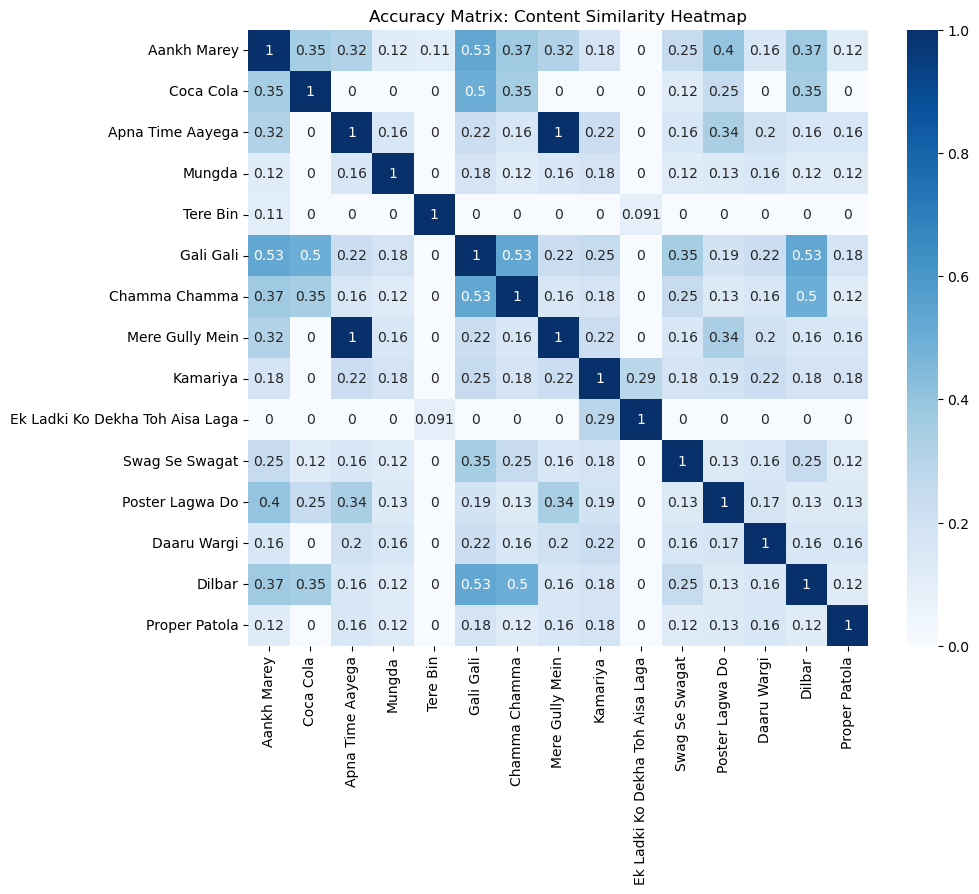

In [6]:
plt.figure(figsize=(10, 8))
sample_sim = similarity[:15, :15] # Visualizing first 15 songs
sns.heatmap(sample_sim, annot=True, cmap='Blues', xticklabels=df['Song-Name'][:15], yticklabels=df['Song-Name'][:15])
plt.title("Accuracy Matrix: Content Similarity Heatmap")
plt.show()

In [7]:
# Save for deployment
pickle.dump(df, open('music_engine_data.pkl', 'wb'))
pickle.dump(similarity, open('similarity_engine.pkl', 'wb'))

print("📁 Project Exported! You are now ready to build a Web App with these .pkl files.")

📁 Project Exported! You are now ready to build a Web App with these .pkl files.
